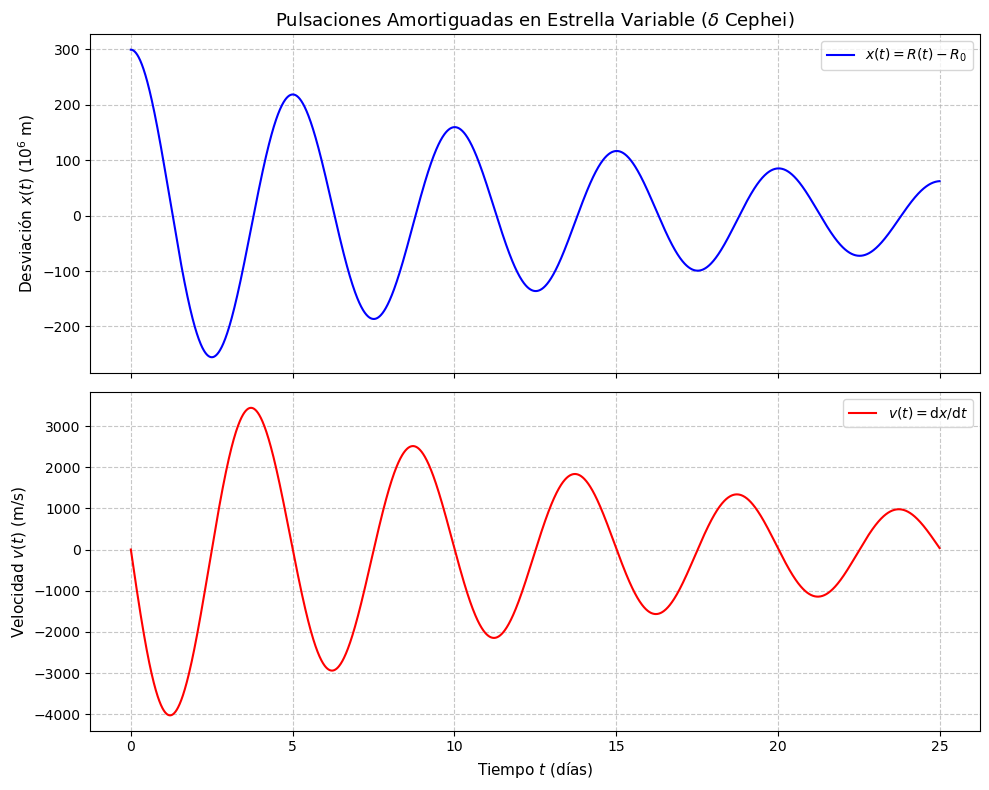

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# 1. Parámetros del problema
P_dias = 5.0                            # Período en días
omega_0 = 2 * np.pi / P_dias            # Frecuencia angular (rad/día)
xi = 0.1                                # Factor de amortiguamiento
R_sun = 7e8                             # Radio solar en metros
R_0 = 42.7 * R_sun                      # Radio medio de Delta Cephei (m)
# Condiciones iniciales
x0 = 0.01 * R_0                         # Desviación inicial (m)
v0 = 0.0                                # Velocidad inicial (m/día)
y0 = np.array([x0, v0])
# 2. Definición del sistema de ODEs de Orden 1
def sistema_ode(t, y):
    x, v = y[0], y[1]
    dxdt = v
    dvdt = -omega_0 * xi * v - (omega_0**2) * x
    return np.array([dxdt, dvdt])
# 3. Implementación del paso_RK4
def paso_RK4(f, t, y, h):
    """Avanza un paso h en el tiempo mediante Runge-Kutta 4."""
    k1 = f(t, y)
    k2 = f(t + 0.5 * h, y + 0.5 * h * k1)
    k3 = f(t + 0.5 * h, y + 0.5 * h * k2)
    k4 = f(t + h, y + h * k3)
    return y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
# 4. Integración temporal
h = 0.01                                # Paso de integración en días
t_max = 25.0                            # Tiempo total de simulación (5 períodos)
num_pasos = int(t_max / h)
t = np.linspace(0, t_max, num_pasos + 1)
y = np.zeros((num_pasos + 1, 2))
y[0] = y0
for i in range(num_pasos):
    y[i+1] = paso_RK4(sistema_ode, t[i], y[i], h)
# Extracción de soluciones
x_t = y[:, 0]                           # Desviación x(t) en metros
v_t_ms = y[:, 1] / 86400.0              # Conversión de velocidad a m/s
# 5. Gráficas
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Gráfica de x(t)
axs[0].plot(t, x_t / 1e6, 'b-', linewidth=1.5, label=r'$x(t) = R(t) - R_0$')
axs[0].set_ylabel('Desviación $x(t)$ ($10^6$ m)', fontsize=11)
axs[0].set_title(r'Pulsaciones Amortiguadas en Estrella Variable ($\delta$ Cephei)', fontsize=13)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].legend(loc='upper right')
# Gráfica de v(t)
axs[1].plot(t, v_t_ms, 'r-', linewidth=1.5, label=r'$v(t) = \mathrm{d}x/\mathrm{d}t$')
axs[1].set_xlabel('Tiempo $t$ (días)', fontsize=11)
axs[1].set_ylabel('Velocidad $v(t)$ (m/s)', fontsize=11)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

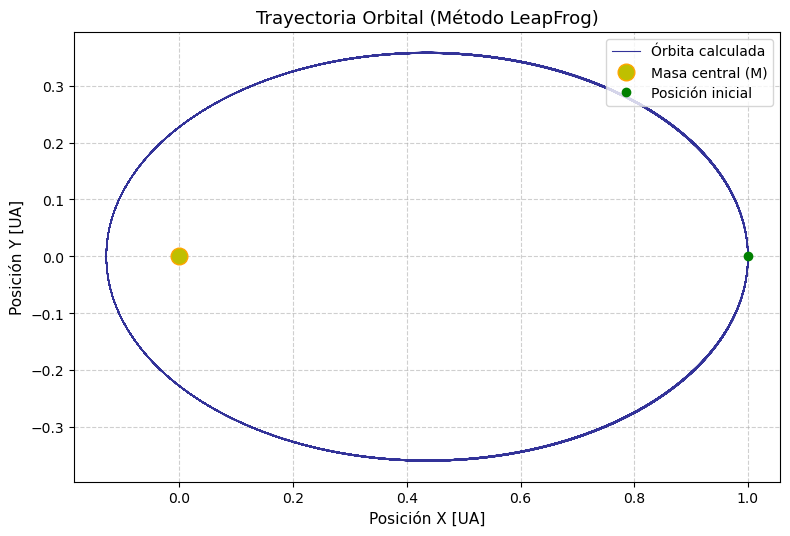

In [2]:
import matplotlib.pyplot as plt
import numpy as np

G = 4.0 * np.pi**2  # Newtonian Gravitational Constant
M = 1.0


def ODE(q0):
    """--------------------------------------------------

    ODEs system for the motion of test body using cartesian
    coordinates in the orbital plane.
    --------------------------------------------------
    Arguments:
    q0: NumPy array with the coordinates defined as
    q0[0] = x: coordinate x
    q0[1] = y: coordinate y
    --------------------------------------------------
    Returns:
    a = NumPy array with the components of the acceleration
    """
    r2 = q0[0] ** 2 + q0[1] ** 2
    a = -G * M * q0[0:2] / r2 ** (3 / 2)
    return a

def LeapFrog(h, q0):
    """LeapFrog method for solving a ODEs system.

    Arguments: h: stepsize for the iteration
               t0: independent parameter initial value
               q0: numpy array with the initial values of the
                   functions in the ODEs system
                   q[0] : x
                   q[1] : y
                   q[2] : dx/dt
                   q[3] : dy/dt
    """
    ax, ay = ODE(q0)
    q1 = np.zeros(q0.shape)
    q1[2] = q0[2] + 2 * h * ax
    q1[3] = q0[3] + 2 * h * ay
    q1[0] = q0[0] + 2 * h * q1[2]
    q1[1] = q0[1] + 2 * h * q1[3]
    return q1

t_0 = 0.0  # (in years)
t_f = 20.0  # (in years)
n = 500000  # Number of steps in the grid
h = (t_f - t_0) / n  # Constant stepsize

t = np.linspace(t_0, t_f, n)  # Time information
Q = np.zeros([n, 4])  # Motion information

# Initial Conditions
Q[0, 0] = 1.0  # initial x
Q[0, 1] = 0.0  # initial y
Q[0, 2] = 0.0  # initial vx
Q[0, 3] = 3.0  # initial vy

# Half step backwards to initialize the velocity
ax0, ay0 = ODE(Q[0])
Q[0, 2] = Q[0, 2] - h * ax0
Q[0, 3] = Q[0, 3] - h * ay0

# Main loops for solving the problem
for i in range(1, n):
    Q[i, :] = LeapFrog(h, Q[i - 1, :])

#Se grafica la órbita
x_pos = Q[:, 0]
y_pos = Q[:, 1]

fig, ax = plt.subplots(figsize=(8, 8))

# Trazado del cuerpo central y la trayectoria
ax.plot(
    x_pos, y_pos, label='Órbita calculada', color='navy', linewidth=0.8, alpha=0.8
)
ax.plot(0, 0, 'yo', markersize=12, markeredgecolor='orange', label='Masa central (M)')
ax.plot(x_pos[0], y_pos[0], 'go', markersize=6, label='Posición inicial')

# Ajuste de aspecto
ax.set_aspect('equal', adjustable='box')

# Configuración de etiquetas y formato
ax.set_title('Trayectoria Orbital (Método LeapFrog)', fontsize=13)
ax.set_xlabel('Posición X [UA]', fontsize=11)
ax.set_ylabel('Posición Y [UA]', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

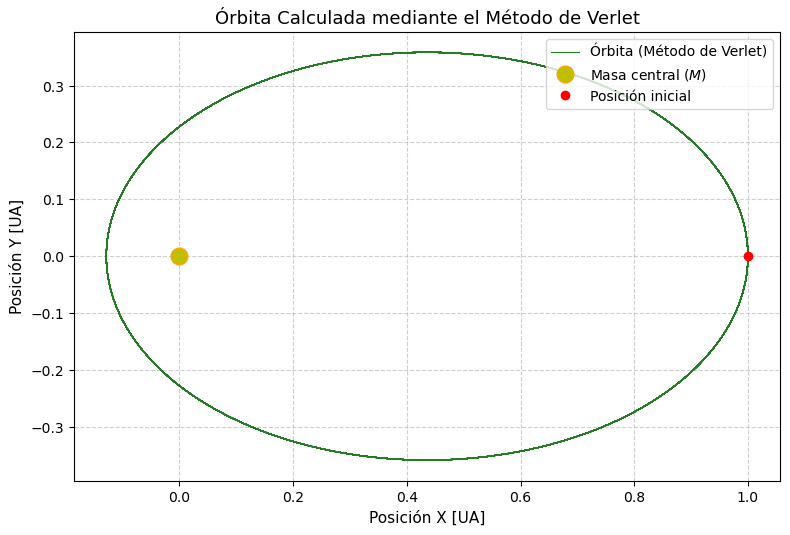

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# 1. Definición de Constantes y ODE
G = 4.0 * np.pi**2  # Constante gravitacional newtoniana
M = 1.0

def ODE(q0):
    """Calcula las componentes de aceleración gravitacional.

    q0[0] = x, q0[1] = y
    """
    r2 = q0[0] ** 2 + q0[1] ** 2
    a = -G * M * q0[0:2] / r2 ** (3 / 2)
    return a
    
#Método de Verlet (Imagen 1)
def Verlet(h, q0, s0):
    """Método de Verlet para integrar el sistema de ODEs.

    q0: posición/velocidad en el paso n [x(n), y(n), vx(n), vy(n)] s0: posición
    en el paso n-1 [x(n-1), y(n-1)]
    """
    ax, ay = ODE(q0)
    q1 = np.zeros(q0.shape)
    q1[0] = 2 * q0[0] - s0[0] + ax * h**2  #
    q1[1] = 2 * q0[1] - s0[1] + ay * h**2  
    q1[2] = (q1[0] - s0[0]) / (2 * h)  
    q1[3] = (q1[1] - s0[1]) / (2 * h)  
    return q1

#Parámetros de Simulación e Integración
t_0 = 0.0  # (in years)
t_f = 20.0  # (in years)
n = 1000000  # Number of steps in the grid
h = (t_f - t_0) / n  # Constant stepsize

t = np.linspace(t_0, t_f, n)  # Time information
Q = np.zeros([n, 4])  # Motion information

# Condiciones Iniciales
Q[0, 0] = 1.0  # initial x
Q[0, 1] = 0.0  # initial y
Q[0, 2] = 0.0  # initial vx
Q[0, 3] = 3.0  # initial vy

# Paso hacia atrás para inicializar S = (x_{-1}, y_{-1})
S = np.zeros(2)  
ax0, ay0 = ODE(Q[0])  
S[0] = Q[0, 0] - h * Q[0, 2] - 0.5 * ax0 * h**2  
S[1] = Q[0, 1] - h * Q[0, 3] - 0.5 * ay0 * h**2  
Q[1, :] = Verlet(h, Q[0, :], S)  

# Bucle de integración temporal
for i in range(2, n):
    Q[i, :] = Verlet(h, Q[i - 1, :], Q[i - 2, 0:2])  

x_pos = Q[:, 0]
y_pos = Q[:, 1]

fig, ax = plt.subplots(figsize=(8, 8))

# Trazo de trayectoria y masa central
ax.plot(
    x_pos,
    y_pos,
    label='Órbita (Método de Verlet)',
    color='darkgreen',
    linewidth=0.8,
    alpha=0.85,
)
ax.plot(
    0,
    0,
    'yo',
    markersize=12,
    markeredgecolor='orange',
    label=r'Masa central ($M$)',
)
ax.plot(x_pos[0], y_pos[0], 'ro', markersize=6, label='Posición inicial')

# Escala igual 1:1 para evitar distorsiones en los ejes
ax.set_aspect('equal', adjustable='box')

# Formato de la gráfica
ax.set_title(r'Órbita Calculada mediante el Método de Verlet', fontsize=13)
ax.set_xlabel('Posición X [UA]', fontsize=11)
ax.set_ylabel('Posición Y [UA]', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [4]:
import math

# 1. Función a maximizar y Valor Exacto
def A(theta):
    """Área de la sección transversal del canal."""
    return 4 * math.sin(theta) * (1 + math.cos(theta)) 


theta_exacto = math.pi / 3  # 1.04719755 rad (60°)
A_exacto = A(theta_exacto)  # 5.1961524...

# 2. Inicialización de Parámetros
xl = 0.0  # Límite inferior inicial
xu = math.pi / 2.0  # Límite superior inicial
epsilon = 0.05  # Tolerancia

phi = (math.sqrt(5) - 1) / 2.0  # Razón áurea d = (sqrt(5)-1)/2 * (xu - xl)

# Paso 1: Puntos intermedios iniciales
d = phi * (xu - xl)
x1 = xl + d
x2 = xu - d

# Paso 2: Evaluar la función
f1 = A(x1)
f2 = A(x2)

paso = 0

print(
    f"{'Paso':<6}{'xl':<10}{'xu':<10}{'|xu - xl|':<12}{'x1':<10}{'x2':<10}{'f(x1)':<10}{'f(x2)':<10}"
)
print("-" * 78)

# 3. Bucle del Algoritmo de la Sección Áurea
while (xu - xl) >= epsilon:  #[cite: 8]
    paso += 1
    ancho = xu - xl
    print(
        f"{paso:<6}{xl:<10.5f}{xu:<10.5f}{ancho:<12.5f}{x1:<10.5f}{x2:<10.5f}{f1:<10.5f}{f2:<10.5f}"
    )

    # Paso 3: Actualizar el intervalo según maximización[cite: 8]
    if f1 > f2:  #[cite: 8]
        xl = x2  #[cite: 8]
        x2 = x1  #[cite: 8]
        f2 = f1
        x1 = xl + phi * (xu - xl)  #[cite: 8]
        f1 = A(x1)
    else:  #[cite: 8]
        xu = x1  #[cite: 8]
        x1 = x2  #[cite: 8]
        f1 = f2
        x2 = xu - phi * (xu - xl)  #[cite: 8]
        f2 = A(x2)

# 4. Cálculo de Resultados Finales y Error Relativo
theta_opt = (xl + xu) / 2.0 
A_opt = A(theta_opt)
error_relativo = (abs(theta_opt - theta_exacto) / theta_exacto) * 100

print("-" * 78)
print(
    f"Criterio de tolerancia (|xu - xl| < {epsilon}) alcanzado en el PASO: {paso}"
)
print(f"Ángulo aproximado (theta*): {theta_opt:.6f} rad")
print(f"Ángulo exacto (theta*):     {theta_exacto:.6f} rad")
print(f"Área aproximada A(theta*):   {A_opt:.6f}")
print(f"Área exacta A(theta*):       {A_exacto:.6f}")
print(f"Error relativo en theta*:   {error_relativo:.4f}%")

Paso  xl        xu        |xu - xl|   x1        x2        f(x1)     f(x2)     
------------------------------------------------------------------------------
1     0.00000   1.57080   1.57080     0.97081   0.59999   5.16543   4.12260   
2     0.59999   1.57080   0.97081     1.19998   0.97081   5.07911   5.16543   
3     0.59999   1.19998   0.59999     0.97081   0.82917   5.16543   4.94182   
4     0.82917   1.19998   0.37081     1.05834   0.97081   5.19551   5.16543   
5     0.97081   1.19998   0.22918     1.11244   1.05834   5.17433   5.19551   
6     0.97081   1.11244   0.14164     1.05834   1.02491   5.19551   5.19356   
7     1.02491   1.11244   0.08754     1.07901   1.05834   5.19093   5.19551   
8     1.02491   1.07901   0.05410     1.05834   1.04557   5.19551   5.19614   
------------------------------------------------------------------------------
Criterio de tolerancia (|xu - xl| < 0.05) alcanzado en el PASO: 8
Ángulo aproximado (theta*): 1.041625 rad
Ángulo exacto (theta*): 

Paso  T_l (K)     T_u (K)     |T_u-T_l|   T1 (K)      T2 (K)      P(T1)         P(T2)         
--------------------------------------------------------------------------------------------
1     3000.00     50000.00    47000.00    32047.60    20952.40    3.5050e+08    2.8544e+08    
2     20952.40    50000.00    29047.60    38904.81    32047.60    3.2014e+08    3.5050e+08    
3     20952.40    38904.81    17952.40    32047.60    27809.61    3.5050e+08    3.4588e+08    
4     27809.61    38904.81    11095.19    34666.82    32047.60    3.4339e+08    3.5050e+08    
5     27809.61    34666.82    6857.21     32047.60    30428.83    3.5050e+08    3.5132e+08    
6     27809.61    32047.60    4237.99     30428.83    29428.38    3.5132e+08    3.5029e+08    
7     29428.38    32047.60    2619.22     31047.14    30428.83    3.5136e+08    3.5132e+08    
8     30428.83    32047.60    1618.77     31429.28    31047.14    3.5117e+08    3.5136e+08    
9     30428.83    31429.28    1000.45     31047.14  

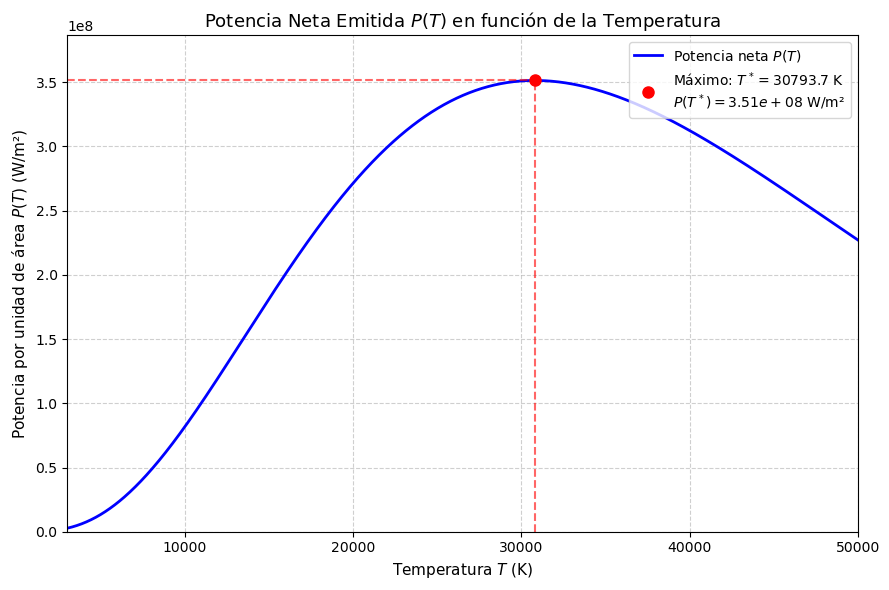

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Parámetros del problema y Modelo de Potencia P(T)
sigma = 5.67e-8  # W / (m^2 * K^4)
T0 = 10000.0  # K
hv_kB = 5000.0  # K (h*nu / k_B)


def P(T):
    """Modelo simplificado para la potencia neta emitida por unidad de área."""
    return (
        sigma
        * (T**4)
        * np.exp(-T / T0)
        * (1.0 - np.exp(-hv_kB / T))  #
    )


# 2. Algoritmo de la Sección Áurea (Maximización)
xl = 3000.0  # Límite inferior (K)[cite: 9]
xu = 50000.0  # Límite superior (K)[cite: 9]
epsilon = 50.0  # Tolerancia (K)[cite: 9]

phi = (np.sqrt(5) - 1) / 2.0  # Razón áurea (~0.618034)

# Paso 1: Puntos intermedios iniciales
d = phi * (xu - xl)
x1 = xl + d
x2 = xu - d

# Paso 2: Evaluación inicial de la función
f1 = P(x1)
f2 = P(x2)

paso = 0

print(
    f"{'Paso':<6}{'T_l (K)':<12}{'T_u (K)':<12}{'|T_u-T_l|':<12}{'T1 (K)':<12}{'T2 (K)':<12}{'P(T1)':<14}{'P(T2)':<14}"
)
print("-" * 92)

# Paso 3 y Criterio de Tolerancia
while (xu - xl) >= epsilon:  #[cite: 9]
    paso += 1
    ancho = xu - xl
    print(
        f"{paso:<6}{xl:<12.2f}{xu:<12.2f}{ancho:<12.2f}{x1:<12.2f}{x2:<12.2f}{f1:<14.4e}{f2:<14.4e}"
    )

    if f1 > f2:
        xl = x2
        x2 = x1
        f2 = f1
        x1 = xl + phi * (xu - xl)
        f1 = P(x1)
    else:
        xu = x1
        x1 = x2
        f1 = f2
        x2 = xu - phi * (xu - xl)
        f2 = P(x2)

# 3. Resultados de la parte (a)
T_opt = (xl + xu) / 2.0
P_max = P(T_opt)

print("-" * 92)
print(f"a) Criterio de tolerancia (|T_u - T_l| < {epsilon} K) alcanzado en el PASO: {paso}")
print(f"   Temperatura óptima encontrada T*: {T_opt:.2f} K")
print(f"   Potencia neta máxima P(T*):      {P_max:.4e} W/m²")

# 4. Gráfica de P(T) e indicación del Máximo - parte (b)
T_vals = np.linspace(3000, 50000, 1000)
P_vals = P(T_vals)

plt.figure(figsize=(9, 6))
plt.plot(T_vals, P_vals, 'b-', linewidth=2, label=r'Potencia neta $P(T)$')
plt.plot(
    T_opt,
    P_max,
    'ro',
    markersize=8,
    label=f'Máximo: $T^* = {T_opt:.1f}$ K\n$P(T^*) = {P_max:.2e}$ W/m²',
)

# Líneas guía discontinuas hacia los ejes
plt.vlines(
    T_opt,
    0,
    P_max,
    colors='r',
    linestyles='--',
    alpha=0.6,
)
plt.hlines(
    P_max,
    3000,
    T_opt,
    colors='r',
    linestyles='--',
    alpha=0.6,
)

plt.title(
    r'Potencia Neta Emitida $P(T)$ en función de la Temperatura', fontsize=13
)
plt.xlabel('Temperatura $T$ (K)', fontsize=11)
plt.ylabel(r'Potencia por unidad de área $P(T)$ (W/m²)', fontsize=11)
plt.xlim(3000, 50000)
plt.ylim(0, P_max * 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()